In [10]:
import pandas as pd
import numpy as np
# import matplotlib.pyplot as plt 
# import itertools
# import json

In [11]:
loc = r"D:\دفاع و مقاله\mahmoudi data\saeed mahmoodi\4.0KHz\4.0.xlsx"
# loc = r"C:\Users\mahmoudi.s\Desktop\دفاع و مقاله\mahmoudi data\saeed mahmoodi\4.0KHz\4.0.xlsx"
# loc = r"C:\Users\user\Desktop\mahmoudi data\saeed mahmoodi\4.0KHz\4.0.xlsx"

In [12]:
sheets = pd.read_excel(loc, sheet_name=None)
n = []
for sheet_name, df in sheets.items():
  
    wavelength_channel =  df.iloc[5:, 0]
    n= n + list(wavelength_channel)
n

[199.9218775396917,
 200.0680543122186,
 200.21422197130983,
 200.36038051299835,
 200.50652993331707,
 200.65267022829892,
 200.79880139397682,
 200.94492342638372,
 201.09103632155256,
 201.23714007551627,
 201.38323468430772,
 201.52932014395992,
 201.67539645050576,
 201.82146359997816,
 201.96752158841008,
 202.11357041183444,
 202.25961006628415,
 202.40564054779216,
 202.55166185239142,
 202.6976739761148,
 202.84367691499529,
 202.98967066506577,
 203.13565522235922,
 203.28163058290852,
 203.42759674274666,
 203.5735536979065,
 203.719501444421,
 203.86543997832314,
 204.01136929564578,
 204.1572893924219,
 204.30320026468436,
 204.44910190846616,
 204.5949943198002,
 204.74087749471943,
 204.88675142925675,
 205.0326161194451,
 205.17847156131742,
 205.32431775090663,
 205.47015468424567,
 205.61598235736747,
 205.76180076630496,
 205.90760990709106,
 206.0534097757587,
 206.19920036834083,
 206.34498168087035,
 206.49075370938021,
 206.63651644990333,
 206.78226989847266,
 2

In [13]:
columns = ['frequency', 'voltag'] + n
new_data = pd.DataFrame(columns= columns)
new_data.astype(float)

,frequency,voltag,199.921878,200.068054,200.214222,200.360381,200.50653,200.65267,200.798801,200.944923,...,1071.944834,1072.003497,1072.062134,1072.120744,1072.179327,1072.237884,1072.296415,1072.354919,1072.413396,1072.471847


In [14]:
loc2 = r"D:\دفاع و مقاله\mahmoudi data\saeed mahmoodi"
# loc2 = r"C:\Users\mahmoudi.s\Desktop\دفاع و مقاله\mahmoudi data\saeed mahmoodi"


In [ ]:
import os
import pandas as pd
import numpy as np
from joblib import Parallel, delayed
from tqdm import tqdm

wavelengths = n  # up to 8173 values

v = np.arange(4, 21, 0.5)
f = np.arange(4, 21, 0.5)

# Define a function to process each individual file


def process_file(j, i):
    new_folder_name5 = f"{j}KHz"
    new_folder_name4 = f"{i}.xlsx"
    path = os.path.join(loc2, new_folder_name5, new_folder_name4)

    if not os.path.exists(path):
        print(f"not exists: {path}")
        return None

    print(f"found data: {path}")

    try:
        sheets = pd.read_excel(path, sheet_name=None)
    except Exception as e:
        print(f"❌ Error reading file {path}: {e}")
        return None

    k = []
    for sheet_name, df in sheets.items():
        integration_time = list(df.iloc[1:2, 1])[0]/1000
        i_channel = df.iloc[5:, 1].divide(integration_time)
        k.extend(list(i_channel))

    if len(k) != len(wavelengths):
        print(f"⚠ Data length of file {path} does not match wavelengths.")
        return None

    row = {
        'frequency': j,
        'voltag': i,
        **dict(zip(wavelengths, k))
    }
    return row


# Use tqdm to display progress bar
results = Parallel(n_jobs=-1)(
    delayed(process_file)(j, i) for j in tqdm(f) for i in v
)
# Filter out None values (files not found or encountered errors)
temp_data = [res for res in results if res is not None]

# Create a new DataFrame from the collected data
df_temp = pd.DataFrame(temp_data)

100%|██████████| 34/34 [00:37<00:00,  1.09s/it]


In [16]:
df_temp

,frequency,voltag,199.921878,200.068054,200.214222,200.360381,200.50653,200.65267,200.798801,200.944923,...,1071.944834,1072.003497,1072.062134,1072.120744,1072.179327,1072.237884,1072.296415,1072.354919,1072.413396,1072.471847
0,4.0,4.0,137.263830,241.318668,-70.845848,4.427865,119.552368,307.736650,327.662045,-183.756417,...,541.353185,-136.762910,262.128910,239.335092,-472.971730,-273.525820,490.067094,-82.627591,461.574821,22.793818
1,4.0,4.5,141.691695,-61.990117,294.453054,409.577556,177.114619,252.388332,309.950583,-221.393274,...,427.384093,-427.384093,-595.488503,125.366001,-364.701093,105.421410,435.931775,-441.630230,535.654730,-131.064455
2,4.0,5.0,126.194166,210.323610,-24.353260,203.681812,298.880919,363.084969,599.975772,-385.224296,...,438.781002,-293.470411,373.248775,-14.246136,-287.771956,-19.944591,139.612137,-333.359593,-79.778364,-242.184319
3,4.0,5.5,99.626973,309.950583,197.040014,203.681812,205.895744,504.776664,506.990597,305.522718,...,777.839050,-635.377685,552.750094,-222.239728,-276.375047,-341.907275,464.424048,757.894459,-125.366001,-475.820957
4,4.0,6.0,112.910570,216.965408,329.875978,285.597323,250.174399,409.577556,493.707000,-243.532601,...,518.559366,-712.306822,-88.326046,-42.738409,-359.002638,-401.741048,259.279683,321.962684,-524.257821,-287.771956
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
574,20.0,8.5,-39.983168,-9.896824,56.213959,-66.902528,-11.084443,72.444749,-15.439045,-12.272061,...,40.756624,-162.358356,150.331811,-258.570716,183.738881,10.690262,-232.513202,137.637125,169.707912,-80.845108
575,20.0,9.0,-132.221564,-19.001901,27.315233,-32.065709,17.814283,-2.771111,-85.508557,13.063807,...,-75.499976,0.000000,59.464583,-24.721231,26.725655,-98.216783,-271.933543,114.920318,-19.376100,-174.384901
576,20.0,9.5,-1.583492,62.152053,71.653003,-78.382844,83.133319,-22.168885,-167.850130,74.819987,...,-106.234480,33.407069,74.163694,134.296418,39.420342,-81.513249,-183.070739,336.075116,-84.853956,38.084059
577,20.0,10.0,-4.354602,-20.585393,100.551729,-100.947602,66.902528,53.046975,-144.097753,-19.397774,...,22.716807,84.185814,-227.836212,72.827411,48.774321,-134.964560,-360.796348,39.420342,-110.911470,-12.026545


In [17]:
df_temp = df_temp.clip(lower=0)
df_temp

,frequency,voltag,199.921878,200.068054,200.214222,200.360381,200.50653,200.65267,200.798801,200.944923,...,1071.944834,1072.003497,1072.062134,1072.120744,1072.179327,1072.237884,1072.296415,1072.354919,1072.413396,1072.471847
0,4.0,4.0,137.263830,241.318668,0.000000,4.427865,119.552368,307.736650,327.662045,0.000000,...,541.353185,0.000000,262.128910,239.335092,0.000000,0.000000,490.067094,0.000000,461.574821,22.793818
1,4.0,4.5,141.691695,0.000000,294.453054,409.577556,177.114619,252.388332,309.950583,0.000000,...,427.384093,0.000000,0.000000,125.366001,0.000000,105.421410,435.931775,0.000000,535.654730,0.000000
2,4.0,5.0,126.194166,210.323610,0.000000,203.681812,298.880919,363.084969,599.975772,0.000000,...,438.781002,0.000000,373.248775,0.000000,0.000000,0.000000,139.612137,0.000000,0.000000,0.000000
3,4.0,5.5,99.626973,309.950583,197.040014,203.681812,205.895744,504.776664,506.990597,305.522718,...,777.839050,0.000000,552.750094,0.000000,0.000000,0.000000,464.424048,757.894459,0.000000,0.000000
4,4.0,6.0,112.910570,216.965408,329.875978,285.597323,250.174399,409.577556,493.707000,0.000000,...,518.559366,0.000000,0.000000,0.000000,0.000000,0.000000,259.279683,321.962684,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
574,20.0,8.5,0.000000,0.000000,56.213959,0.000000,0.000000,72.444749,0.000000,0.000000,...,40.756624,0.000000,150.331811,0.000000,183.738881,10.690262,0.000000,137.637125,169.707912,0.000000
575,20.0,9.0,0.000000,0.000000,27.315233,0.000000,17.814283,0.000000,0.000000,13.063807,...,0.000000,0.000000,59.464583,0.000000,26.725655,0.000000,0.000000,114.920318,0.000000,0.000000
576,20.0,9.5,0.000000,62.152053,71.653003,0.000000,83.133319,0.000000,0.000000,74.819987,...,0.000000,33.407069,74.163694,134.296418,39.420342,0.000000,0.000000,336.075116,0.000000,38.084059
577,20.0,10.0,0.000000,0.000000,100.551729,0.000000,66.902528,53.046975,0.000000,0.000000,...,22.716807,84.185814,0.000000,72.827411,48.774321,0.000000,0.000000,39.420342,0.000000,0.000000


In [18]:
df = df_temp.copy()

In [ ]:
# 1. Select frequency columns (after voltag)
start_idx = df.columns.get_loc('voltag') + 1
freq_cols = df.columns[start_idx:]

# 2. Calculate total intensity (sum of each row)
total_intensity = df[freq_cols].sum(axis=1)

# 3. Find the maximum of total intensity in the entire dataset
max_total = total_intensity.max()

# 4. Normalization: Scale each row by the overall maximum
factor = total_intensity / max_total
df[freq_cols] = df[freq_cols].multiply(factor, axis=0)

# 5. Drop extra columns (keep only frequency, voltag, and frequency columns)
df = df[['frequency', 'voltag'] + list(freq_cols)]
df
# 6. Result
# print("✅ Normalization completed.")
# print(df.head())

,frequency,voltag,199.921878,200.068054,200.214222,200.360381,200.50653,200.65267,200.798801,200.944923,...,1071.944834,1072.003497,1072.062134,1072.120744,1072.179327,1072.237884,1072.296415,1072.354919,1072.413396,1072.471847
0,4.0,4.0,8.610698,15.138163,0.000000,0.277764,7.499640,19.304629,20.554569,0.000000,...,33.959629,0.00000,16.443610,15.013731,0.000000,0.000000,30.742401,0.000000,28.955052,1.429879
1,4.0,4.5,12.529087,0.000000,26.037008,36.216891,15.661358,22.317436,27.407377,0.000000,...,37.791434,0.00000,0.000000,11.085487,0.000000,9.321887,38.547263,0.000000,47.365264,0.000000
2,4.0,5.0,13.511754,22.519590,0.000000,21.808445,32.001522,38.875923,64.240093,0.000000,...,46.980784,0.00000,39.964174,0.000000,0.000000,0.000000,14.948431,0.000000,0.000000,0.000000
3,4.0,5.5,13.536441,42.113373,26.772073,27.674503,27.975312,68.584637,68.885447,41.511754,...,105.685965,0.00000,75.102847,0.000000,0.000000,0.000000,63.101876,102.976068,0.000000,0.000000
4,4.0,6.0,14.936498,28.701507,43.638005,37.780555,33.094595,54.181416,65.310572,0.000000,...,68.598194,0.00000,0.000000,0.000000,0.000000,0.000000,34.299097,42.591187,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
574,20.0,8.5,0.000000,0.000000,8.842196,0.000000,0.000000,11.395224,0.000000,0.000000,...,6.410829,0.00000,23.646499,0.000000,28.901276,1.681529,0.000000,21.649683,26.694270,0.000000
575,20.0,9.0,0.000000,0.000000,4.493884,0.000000,2.930794,0.000000,0.000000,2.149249,...,0.000000,0.00000,9.783073,0.000000,4.396887,0.000000,0.000000,18.906613,0.000000,0.000000
576,20.0,9.5,0.000000,10.679780,12.312358,0.000000,14.285056,0.000000,0.000000,12.856551,...,0.000000,5.74044,12.743778,23.076571,6.773720,0.000000,0.000000,57.748831,0.000000,6.544102
577,20.0,10.0,0.000000,0.000000,19.268265,0.000000,12.820223,10.165148,0.000000,0.000000,...,4.353117,16.13214,0.000000,13.955581,9.346399,0.000000,0.000000,7.553939,0.000000,0.000000


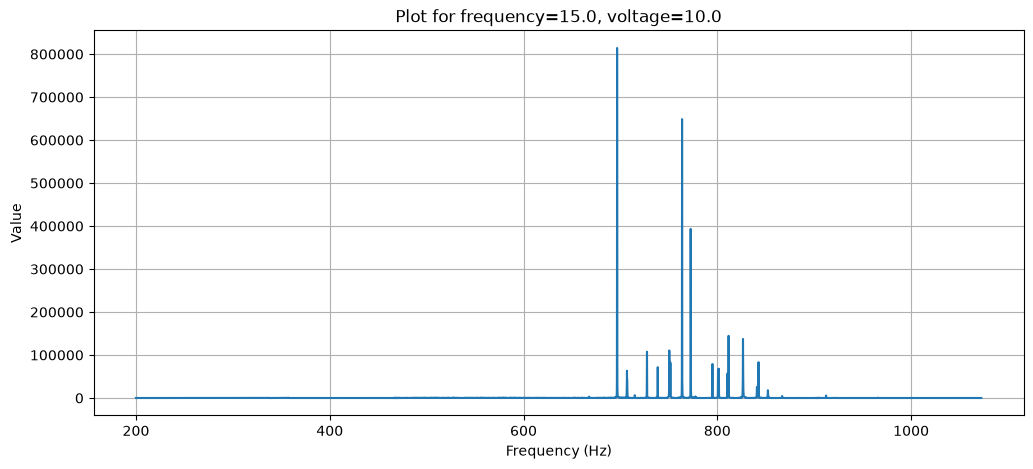

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Find the target row
row = df[(df["frequency"] == 15.0) & (df["voltag"] == 10.0)]

if row.empty:
    print("No row found with these values!")
else:
    # Find the columns after voltag
    start = df.columns.get_loc("voltag") + 1
    all_cols = df.columns[start:]
    
    # Only columns with numeric names (the frequencies themselves)
    cols = [c for c in all_cols if str(c).replace('.', '').isdigit()]
    
    # X-axis = Frequencies
    x = [float(c) for c in cols]
    
    # Y-axis = Values of that row
    y = row[cols].values[0]
    
    # Plot the graph
    plt.figure(figsize=(12, 5))
    plt.plot(x, y)
    plt.xlabel("Frequency (Hz)")
    plt.ylabel("Value")
    plt.title("Plot for frequency=15.0, voltage=10.0")
    plt.grid(True)
    plt.show()

In [39]:
df = df.drop('sum', axis=1)

In [ ]:
df2 = pd.read_csv(r".\ArgonSpect_Oxygen_max_lifeTime.csv")
df['Max_Oxygen_LifeTime'] = df2['Max_Oxygen_LifeTime']
df

C:\Users\fanni\AppData\Local\Temp\ipykernel_2612\1338263270.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['Max_Oxygen_LifeTime'] = df2['Max_Oxygen_LifeTime']


,frequency,voltag,199.921878,200.068054,200.214222,200.360381,200.50653,200.65267,200.798801,200.944923,...,1072.003497,1072.062134,1072.120744,1072.179327,1072.237884,1072.296415,1072.354919,1072.413396,1072.471847,Max_Oxygen_LifeTime
0,4.0,4.0,8.610698,15.138163,0.000000,0.277764,7.499640,19.304629,20.554569,0.000000,...,0.00000,16.443610,15.013731,0.000000,0.000000,30.742401,0.000000,28.955052,1.429879,0.000002
1,4.0,4.5,12.529087,0.000000,26.037008,36.216891,15.661358,22.317436,27.407377,0.000000,...,0.00000,0.000000,11.085487,0.000000,9.321887,38.547263,0.000000,47.365264,0.000000,0.000005
2,4.0,5.0,13.511754,22.519590,0.000000,21.808445,32.001522,38.875923,64.240093,0.000000,...,0.00000,39.964174,0.000000,0.000000,0.000000,14.948431,0.000000,0.000000,0.000000,0.000005
3,4.0,5.5,13.536441,42.113373,26.772073,27.674503,27.975312,68.584637,68.885447,41.511754,...,0.00000,75.102847,0.000000,0.000000,0.000000,63.101876,102.976068,0.000000,0.000000,0.000005
4,4.0,6.0,14.936498,28.701507,43.638005,37.780555,33.094595,54.181416,65.310572,0.000000,...,0.00000,0.000000,0.000000,0.000000,0.000000,34.299097,42.591187,0.000000,0.000000,0.000004
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
574,20.0,8.5,0.000000,0.000000,8.842196,0.000000,0.000000,11.395224,0.000000,0.000000,...,0.00000,23.646499,0.000000,28.901276,1.681529,0.000000,21.649683,26.694270,0.000000,0.000004
575,20.0,9.0,0.000000,0.000000,4.493884,0.000000,2.930794,0.000000,0.000000,2.149249,...,0.00000,9.783073,0.000000,4.396887,0.000000,0.000000,18.906613,0.000000,0.000000,0.000003
576,20.0,9.5,0.000000,10.679780,12.312358,0.000000,14.285056,0.000000,0.000000,12.856551,...,5.74044,12.743778,23.076571,6.773720,0.000000,0.000000,57.748831,0.000000,6.544102,0.000003
577,20.0,10.0,0.000000,0.000000,19.268265,0.000000,12.820223,10.165148,0.000000,0.000000,...,16.13214,0.000000,13.955581,9.346399,0.000000,0.000000,7.553939,0.000000,0.000000,0.000003


In [ ]:
df.to_csv(r"final_data-sari.csv")

In [ ]:
df = pd.read_csv(r"final_data-sari.csv")
df = df.drop(['Unnamed: 0', 'Max_Oxygen_LifeTime'], axis=1, errors='ignore')
df

,frequency,voltag,199.9218775396917,200.0680543122186,200.21422197130983,200.36038051299835,200.50652993331707,200.65267022829892,200.79880139397682,200.94492342638372,...,1071.9448339430508,1072.0034971234381,1072.0621337630776,1072.1207438589693,1072.179327408114,1072.237884407512,1072.2964148541635,1072.3549187450692,1072.4133960772294,1072.4718468476444
0,4.0,4.0,8.610698,15.138163,0.000000,0.277764,7.499640,19.304629,20.554569,0.000000,...,33.959629,0.00000,16.443610,15.013731,0.000000,0.000000,30.742401,0.000000,28.955052,1.429879
1,4.0,4.5,12.529087,0.000000,26.037008,36.216891,15.661358,22.317436,27.407377,0.000000,...,37.791434,0.00000,0.000000,11.085487,0.000000,9.321887,38.547263,0.000000,47.365264,0.000000
2,4.0,5.0,13.511754,22.519590,0.000000,21.808445,32.001522,38.875923,64.240093,0.000000,...,46.980784,0.00000,39.964174,0.000000,0.000000,0.000000,14.948431,0.000000,0.000000,0.000000
3,4.0,5.5,13.536441,42.113373,26.772073,27.674503,27.975312,68.584637,68.885447,41.511754,...,105.685965,0.00000,75.102847,0.000000,0.000000,0.000000,63.101876,102.976068,0.000000,0.000000
4,4.0,6.0,14.936498,28.701507,43.638005,37.780555,33.094595,54.181416,65.310572,0.000000,...,68.598194,0.00000,0.000000,0.000000,0.000000,0.000000,34.299097,42.591187,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
574,20.0,8.5,0.000000,0.000000,8.842196,0.000000,0.000000,11.395224,0.000000,0.000000,...,6.410829,0.00000,23.646499,0.000000,28.901276,1.681529,0.000000,21.649683,26.694270,0.000000
575,20.0,9.0,0.000000,0.000000,4.493884,0.000000,2.930794,0.000000,0.000000,2.149249,...,0.000000,0.00000,9.783073,0.000000,4.396887,0.000000,0.000000,18.906613,0.000000,0.000000
576,20.0,9.5,0.000000,10.679780,12.312358,0.000000,14.285056,0.000000,0.000000,12.856551,...,0.000000,5.74044,12.743778,23.076571,6.773720,0.000000,0.000000,57.748831,0.000000,6.544102
577,20.0,10.0,0.000000,0.000000,19.268265,0.000000,12.820223,10.165148,0.000000,0.000000,...,4.353117,16.13214,0.000000,13.955581,9.346399,0.000000,0.000000,7.553939,0.000000,0.000000
